In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('MRK','XOM'), 
         ('MRK','JNJ'), 
         ('MRK','CVX'), 
         ('AMGN','XOM'), 
         ('AMGN', 'JNJ'),
         ('AMGN', 'CVX'), 
         ('CSCO','XOM'), 
         ('CSCO', 'JNJ'), 
         ('CSCO','CVX')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, 

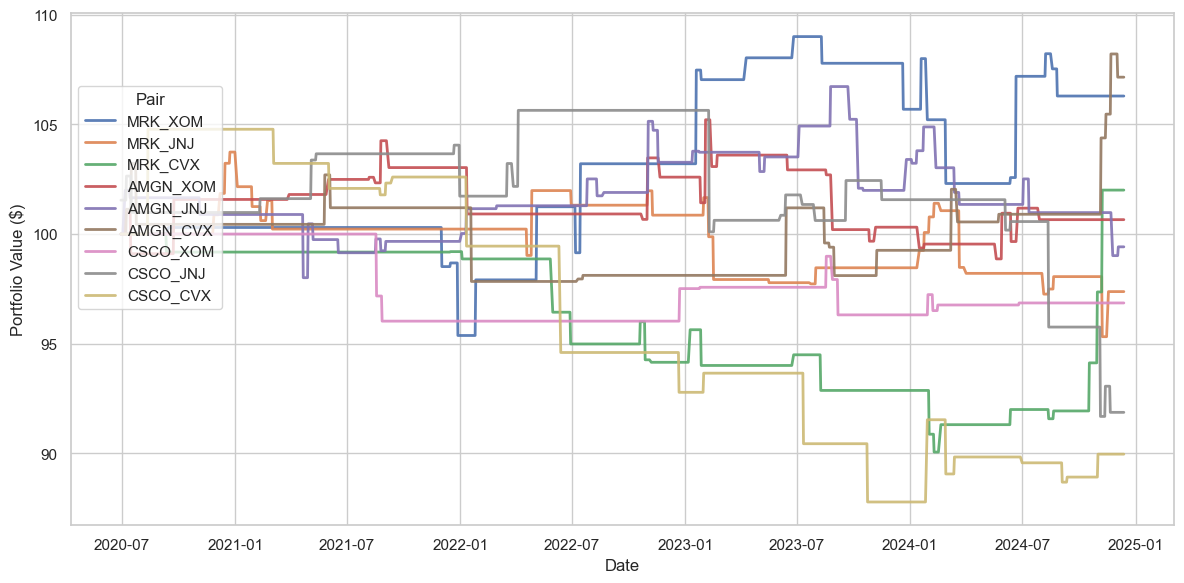

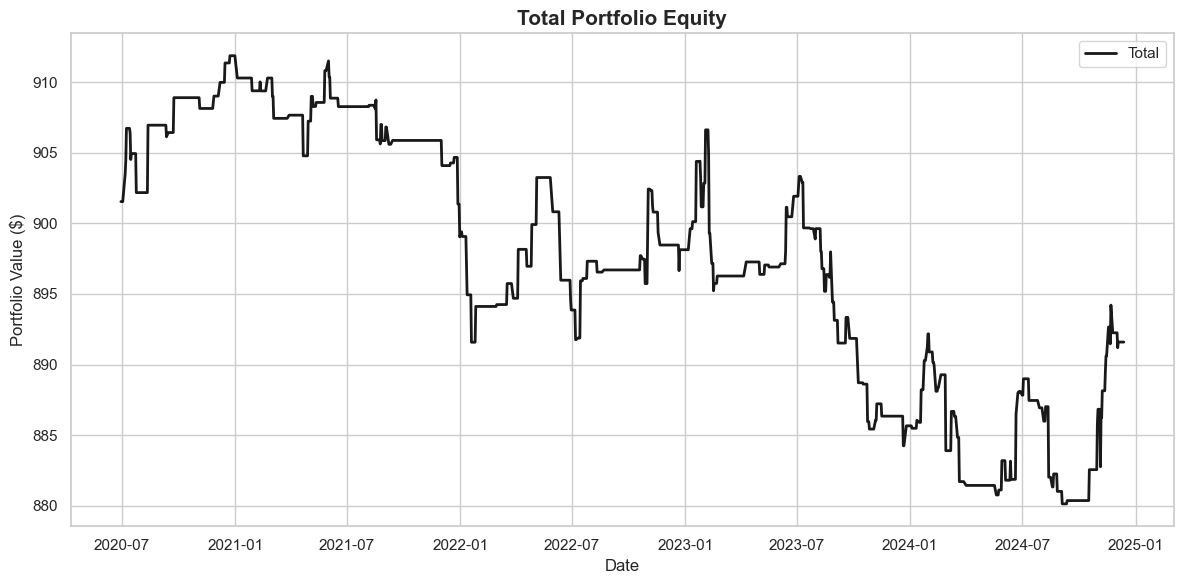

Summary
MRK_XOM: Final Value = $106.29, Total Return = 6.29%, Trades = 22
MRK_JNJ: Final Value = $97.38, Total Return = -2.62%, Trades = 33
MRK_CVX: Final Value = $102.00, Total Return = 2.00%, Trades = 21
AMGN_XOM: Final Value = $100.66, Total Return = 0.66%, Trades = 29
AMGN_JNJ: Final Value = $99.42, Total Return = -0.58%, Trades = 40
AMGN_CVX: Final Value = $107.15, Total Return = 7.15%, Trades = 20
CSCO_XOM: Final Value = $96.86, Total Return = -3.14%, Trades = 11
CSCO_JNJ: Final Value = $91.87, Total Return = -9.52%, Trades = 25
CSCO_CVX: Final Value = $89.97, Total Return = -10.03%, Trades = 19

Total Portfolio Performance
Initial Portfolio Value: $901.54
Final Portfolio Value:   $891.59
Total Return:            -1.10%

Sharpe Ratios
MRK_XOM: Sharpe Ratio = 0.29
MRK_JNJ: Sharpe Ratio = -0.16
MRK_CVX: Sharpe Ratio = 0.13
AMGN_XOM: Sharpe Ratio = 0.06
AMGN_JNJ: Sharpe Ratio = -0.01
AMGN_CVX: Sharpe Ratio = 0.39
CSCO_XOM: Sharpe Ratio = -0.33
CSCO_JNJ: Sharpe Ratio = -0.43
CSCO_CVX

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)